In [92]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    # Array conversions for luminosity values (log10)
    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)
    
    tauabs = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    tauabs[0] = np.array(s['col3'])    
    tauabs[1] = np.array(s['col9'])
    tauabs[2] = np.array(s['col15'])
    tauabs[3] = np.array(s['col21'])
    tauabs[4] = np.array(s['col27'])
    tauabs[5] = np.array(s['col33'])


    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll, tauabs

#identify what folder i am in
#nu, nuLnu, tauabs = grmonty('/home/pedro/gpumontys/gpumonty_last/gpumonty/output/SPHERE_1e6.spec')
#nu_gr, nuLnu_gr = grmonty('/home/pedro/gpumontys/gpumonty_sphere/gpumonty/output/SPHERE.spec')
domega_array = np.array([1.179853e+00, 2.875295e+00, 3.211087e+00, 2.551775e+00, 1.658978e+00, 1.089384e+00])


In [93]:
import h5py
M_SQRT2 = np.sqrt(2)
EE = 4.80320680e-10  # Electron charge in cgs
ME = 9.1093826e-28 # Electron mass in grams
CL = 2.99792458e10   # Speed of light in cm/s
JCST = M_SQRT2 * EE**3 / (27 * ME * CL**2)
CST = 1.88774862536  # 2^(11/12)
CL = 2.99792458e10  # Speed of light in cm/s
ME = 9.1093826e-28  # Electron mass in grams
HPL = 6.6260693e-27
THETAE_MIN = 0.3

# Open the HDF5 file
with h5py.File('../../igrmonty_scattering/spectrum_800.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    LSUN = 3.827e33
    # Extract the datasets 'lnu' and 'nulnu'
    nu_igr = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_igr = output_group['nuLnu'][:] * LSUN
    dOmega_igr = output_group['dOmega'][:]
    
with h5py.File('../../igrmonty_scattering/spectrum_1e6.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    LSUN = 3.827e33
    # Extract the datasets 'lnu' and 'nulnu'
    nu_igr_bef = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_igr_bef = output_group['nuLnu'][:] * LSUN
    dOmega_igr_bef = output_group['dOmega'][:]

In [94]:
nu, nuLnu, tauabs = grmonty('../output/sane_ben.spec')


/tmp/ipykernel_38/2349931235.py:37: RuntimeWarning: divide by zero encountered in divide
  diff = np.abs(nuLnu_avg - y_igr_interp) / y_igr_interp
/tmp/ipykernel_38/2349931235.py:37: RuntimeWarning: invalid value encountered in divide
  diff = np.abs(nuLnu_avg - y_igr_interp) / y_igr_interp


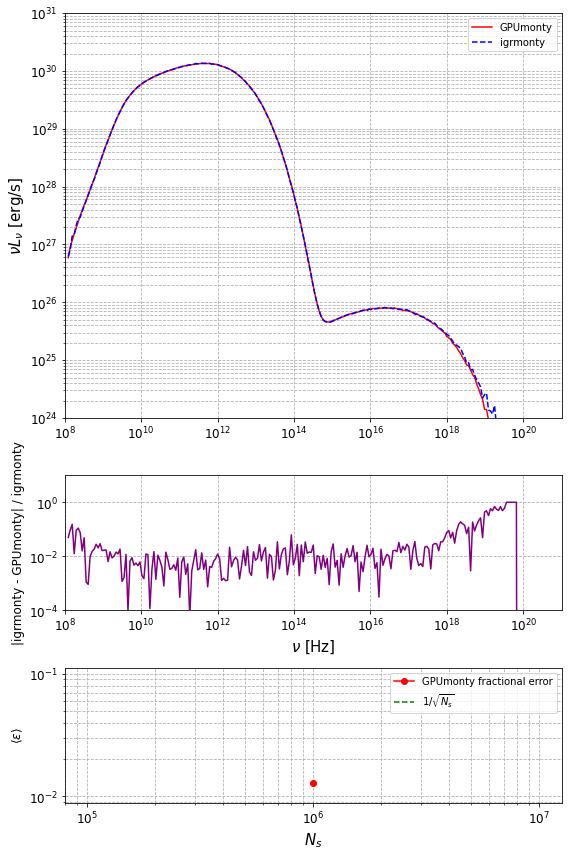

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# --- Top panel: averaged spectrum ---
nuLnu_avg = (nuLnu * domega_array[:, None] / (4 * np.pi)).sum(0)
nuLnu_avg_igrmonty = (nuLnu_igr.sum(0) * dOmega_igr / (4 * np.pi)).sum(1)
nuLnu_avg_igrmonty_bef = (nuLnu_igr_bef.sum(0) * dOmega_igr_bef / (4 * np.pi)).sum(1)

# --- Frequency range for masking (optional, for fractional error calculation) ---
numin = 1e8
numax = 1e16
mask = (nu >= numin) & (nu <= numax)
nu_masked = nu[mask]

# --- Prepare figure with gridspec ---
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1])

# --- Panel 1: spectra ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(nu, nuLnu_avg, linestyle='-', color='red', label='GPUmonty')
ax1.plot(nu_igr, nuLnu_avg_igrmonty, linestyle='--', color='blue', label='igrmonty')
#ax1.plot(nu_igr_bef, nuLnu_avg_igrmonty_bef, linestyle='--', color='purple', label='igrmonty')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\nu L_\nu$ [erg/s]", fontsize=15)
ax1.set_xlim(1e8, 1e21)
ax1.set_ylim(1e24, 1e31)
ax1.grid(True, which="both", ls="--")
ax1.legend()
ax1.tick_params(axis='both', which='major', labelsize=12)

# --- Panel 2: relative difference ---
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
y_igr_interp = np.interp(nu, nu_igr, nuLnu_avg_igrmonty)
diff = np.abs(nuLnu_avg - y_igr_interp) / y_igr_interp
diff = np.nan_to_num(diff, nan=1e-40, posinf=1e-40, neginf=1e-40)
ax2.plot(nu, diff, color='purple')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r"$\nu$ [Hz]", fontsize=15)
ax2.set_ylabel("|igrmonty - GPUmonty| / igrmonty", fontsize=12)
ax2.set_ylim(1e-4, 1e1)
ax2.grid(True, which="both", ls="--")
ax2.tick_params(axis='both', which='major', labelsize=12)
#ax2.axvline(4e8)
# --- Panel 3: fractional error vs Ns (example with multiple N_s datasets) ---
ax3 = fig.add_subplot(gs[2, 0])
Ns_array = np.array([1e6])
y_list = [nuLnu]  # your simulation outputs
epsilon_avg_list = []

for y_sim in y_list:
    y_simdata = (y_sim * domega_array[:, None] / (4 * np.pi)).sum(0)
    y_igr_interp = np.interp(nu, nu_igr, nuLnu_avg_igrmonty)
    y_sim_masked = y_simdata[mask]
    y_igr_masked = y_igr_interp[mask]
    frac_error = np.abs(y_sim_masked - y_igr_masked) / y_igr_masked
    frac_error = np.nan_to_num(frac_error, nan=1e-40, posinf=1e-40, neginf=1e-40)
    dlnnu = np.log(nu_masked[1:] / nu_masked[:-1])
    epsilon_avg = np.sum(frac_error[1:] * dlnnu) / np.log(numax/numin)
    epsilon_avg_list.append(epsilon_avg)

epsilon_avg_list = np.array(epsilon_avg_list)

# Plot fractional error vs Ns
ax3.plot(Ns_array, epsilon_avg_list, 'o-', color='red', label='GPUmonty fractional error')
ax3.plot(Ns_array, epsilon_avg_list[0]*(Ns_array[0]/Ns_array)**0.5, '--', color='green', label=r'1/$\sqrt{N_s}$')

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel(r"$N_s$", fontsize=15)
ax3.set_ylabel(r"$\langle \epsilon \rangle$", fontsize=12)
ax3.grid(True, which="both", ls="--")
ax3.legend()
ax3.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
#plt.savefig("spectra_comparison_full.png", dpi=300)
plt.show()


In [69]:
import h5py

def print_h5_structure(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"[GROUP]   {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"[DATASET] {name} shape={obj.shape} dtype={obj.dtype}")

with h5py.File("../../igrmonty_scattering/", "r") as f:
    f.visititems(print_h5_structure)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../igrmonty_scattering/hotcross_edf_kappa_var.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [6]:
with h5py.File("../../igrmonty/hotcross_edf_kappa_var.h5", "r") as f:
    data = f["table"][:]   # 3D array (770, 221, 81)
# Flatten the 3D array
flat = data[98].flatten()

# Print the first 10 values
for value in flat[:10]:
    print(value)



-24.176617690446015
-24.176617739511883
-24.17661780129431
-24.17661787906927
-24.17661797698651
-24.176618100255297
-24.17661825544676
-24.176618450825845
-24.17661869680513
-24.176619006491084


In [92]:
data.shape

(770, 221, 81)

In [ ]:

For 1e6 - GPUmonty
Number of superphotons made: 18.443.771
Number of superphotons scattered: 1948844
Number of superphotons recorded: 7141658

For 1e6 - igrmonty
N_superph_made = 16.979.201
N_superph_scatt = 199237
N_superph_recorded = 4524323